In [1]:
import torch

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("dataset/final_processed_data.csv") #load dataset

In [4]:
embedding_cache = torch.load("biobert_smiles_embeddings.pt") # load embeddings

emb_s1 = torch.stack([embedding_cache[s] for s in df["SMILES1"]])
emb_s2 = torch.stack([embedding_cache[s] for s in df["SMILES2"]])

In [5]:
def smiles_to_fp(smiles): #converting smiles to rdkit fingerprints
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

In [7]:
sample_size = 2000 # sample size for similarity calculations, try full later
np.random.seed(42)
indices = np.random.choice(len(df), sample_size, replace=False)

tanimoto_sims = []
cosine_sims = []

In [8]:
for i in indices:
    s1 = df.iloc[i]["SMILES1"]
    s2 = df.iloc[i]["SMILES2"]
    
    fp1 = smiles_to_fp(s1)
    fp2 = smiles_to_fp(s2)
    
    if fp1 is None or fp2 is None:
        continue
    
    # Tanimoto similarity
    tanimoto = DataStructs.TanimotoSimilarity(fp1, fp2)
    
    # Embedding (cosine) similarity
    cos_sim = cosine_similarity(
        emb_s1[i].reshape(1, -1),
        emb_s2[i].reshape(1, -1)
    )[0][0]
    
    tanimoto_sims.append(tanimoto)
    cosine_sims.append(cos_sim)

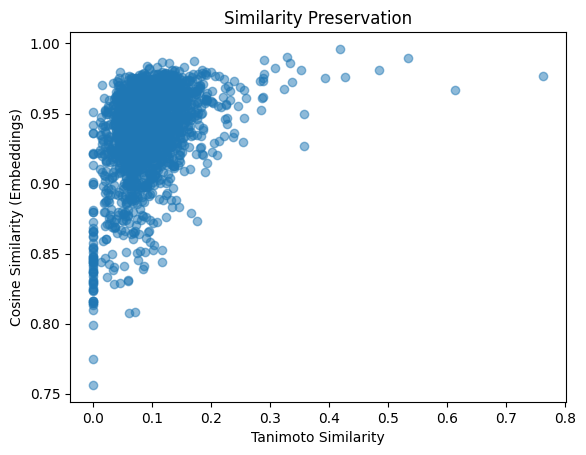

In [9]:
import matplotlib.pyplot as plt

plt.scatter(tanimoto_sims, cosine_sims, alpha=0.5)
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Cosine Similarity (Embeddings)")
plt.title("Similarity Preservation")
plt.show()